# Working with linear regression emulators

This notebook introduces the use of emulators using a very simple linear regression emulator that is included in our package.

## Libraries, global parameters, and initialization

The basic libraries for numerical analysis are used throughout the notebook, namely, `numpy` and `pandas`. We also use the `LinearModel` emulator from our library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import history_matching.emulators as emulators

%matplotlib inline

/home/rnunez/anaconda3/envs/20220920-hm-emulators/lib/python3.9/site-packages/skcuda/cublas.py:284: UserWarning: creating CUBLAS context to get version number
  warnings.warn('creating CUBLAS context to get version number')


## Building a simple linear model

Let's define a linear model in 1 dimension. In its simplest form, this model receives a single parameter $\theta$ and outputs a scalar. This scalar is computed as $b_0 + b_1 \theta + \mathcal{N}(0, \sigma)$, with $b_0$, $b_1$, and $\sigma$ being hyper-parameters that, for all the purposes in this example, are constant (and unknown to the emulator).

In the Python function that implements this model, we extend this definition and apply it to a set of parameters ${\theta}$, which are defined as separate rows of an input dataframe `x`. Consequently, this function computes the corresponding outputs and returns them in an output dataframe.

In [2]:
def linear_model( x: pd.DataFrame(), b0=1, b1=2, sigma=7.5 ):
    """
    1-D linear model. Using the value of theta in each row of the 
    input dataframe, the model computes outputs in an output dataframe
    as: 
            b0 + b1*theta + mu,
    with mu being drawn from a 0-mean normal distribution with standard
    deviation sigma.
    """
    y = b0 + b1*x['theta'] + np.random.normal( 0, sigma, len(x) )
    y = y.to_frame( name='out' )
    y.index = x.index
    return y

Now, let's see how this model works. We can do that by defining the parameter space as the interval [`theta_min`, `theta_max`], and then sampling some points in that space. We then call our model and plot the outputs. As expected in this case, we see that the output is a noisy line.

<AxesSubplot: title={'center': 'Linear model'}, xlabel='theta', ylabel='data'>

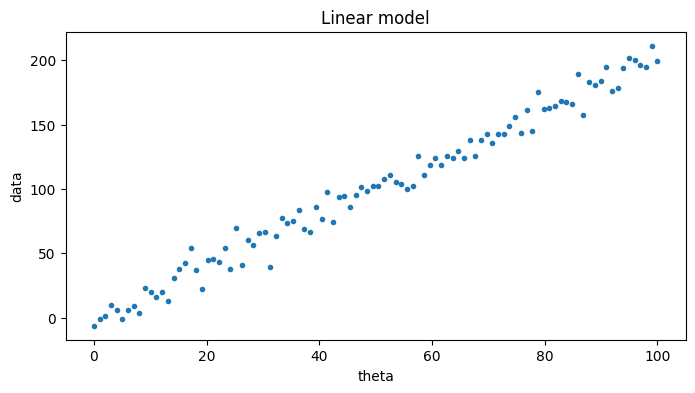

In [3]:
# Sample parameters from a grid
theta_min = 0
theta_max = 100
n = 100
x = pd.DataFrame( { 'theta' : np.linspace( theta_min, theta_max, n ) } )

# Run the model and plot outputs
y = linear_model(x)
xy_model = pd.DataFrame( { 'theta' : x['theta'].values,
                           'data'  : y['out'].values
                          } )

xy_model.plot( title='Linear model', x='theta', y='data', ylabel='data', legend=False, style='.', figsize=(8,4))

## Using a linear regression emulator

An emulator is a function that allows us to predict the output of a model for a set of input parameters, along with some uncertainty measures. The `emulators` module of our package contains some emulators. One of the most basic emulators is the linear regression emulator. This emulator is defined by the `emulators.LinearModel` class. 

We can train our emulator by instantiating it with some input data (such as the one created above using the linear model), and then calling the `train()` method, as follows:

In [4]:
my_emulator = emulators.LinearModel(x, y)
my_emulator.train()

We can get information about the emulator object by using the `info()` method:

In [5]:
my_emulator.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  100
      Number of training samples =  75
      Number of testing samples =  25

... Emulator configuration:
      coefficients:  [[2.04034162]]
      intercept   :  [-1.77009317]

      This emulator has not been tested yet


Note that the general information above contains a default number of testing and training samples. We can explicitly indicate what fraction of the data to use for testing by setting the `test_fraction` argument when instantiating the emulator object. For example, if we want to use 50% of the data for testing, we can set our emulator as `my_emulator = emulators.LinearModel(x, y, test_fraction=0.5)`.

Once we have trained our emulator, we can use it for predicting some outputs:

In [6]:
x_predict = pd.DataFrame( { 'theta' : np.linspace( theta_max+1, 2*theta_max, n ) } )
y_predict = my_emulator.predict( x_predict )
print( y_predict.head() )

        value         low        high
0  204.304410  104.809997  303.798823
1  206.344752  106.850339  305.839165
2  208.385093  108.890681  307.879506
3  210.425435  110.931022  309.919848
4  212.465777  112.971364  311.960190


Let's compare the training and predicted data:

<AxesSubplot: xlabel='theta', ylabel='output'>

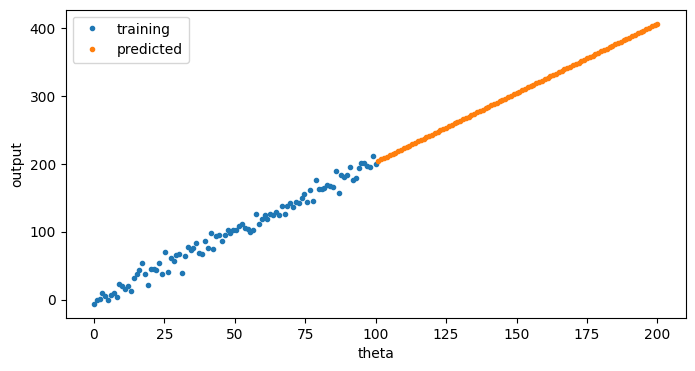

In [7]:
fig_pred, ax_pred = plt.subplots(1, 1, figsize=(8,4) )
xy = pd.DataFrame( { 'theta'    : x['theta'].values ,
                     'training' : y['out'].values
                    } )
xy = pd.concat( [ xy, pd.DataFrame( { 'theta' : x_predict['theta'].values,
                                      'predicted' : y_predict['value'].values
                                     } ) 
                 ], ignore_index=True )
xy.plot(x='theta', style='.', ylabel='output', ax=ax_pred )

In addition to the predicted value, the `predict()` method gives us some lower and upper uncertainty bounds. In this emulator, those bounds are defined by default by the 5th and 95th percentiles of the normal distribution centered at the predicted value, and with variance estimated from the training data. We can change these percentiles by modifying some arguments in the call for predicting outputs:

In [8]:
y_predict_new_quantiles = my_emulator.predict( x_predict, qlow=0.25, qhi=0.75 )
print( y_predict_new_quantiles.head() )

        value         low        high
0  204.304410  163.505666  245.103154
1  206.344752  165.546008  247.143496
2  208.385093  167.586350  249.183837
3  210.425435  169.626691  251.224179
4  212.465777  171.667033  253.264520


## Evaluating the performance of our emulator

We can run some diagnostics and evaluate the performance of our emulator using the `test()` method:

In [9]:
my_emulator.test()

A summary of the performance results can now be seen when calling the `info()` method:

In [10]:
my_emulator.info()

... General information:
      Number of parameters =  1
      Number of samples (total) =  100
      Number of training samples =  75
      Number of testing samples =  25

... Emulator configuration:
      coefficients:  [[2.04034162]]
      intercept   :  [-1.77009317]

... Performance results:
      MSE =  36.29046606963925
      R2  =  nan


We can get more detailed information by plotting diagnostics. These are a set of figures that can provide some deeper information that the one that is quantified in the summarized performance results. 

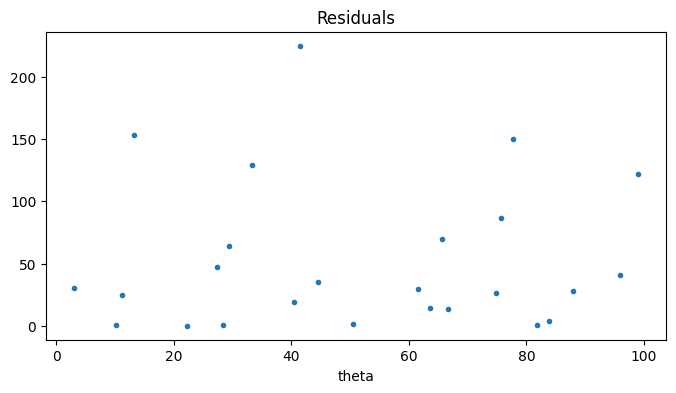

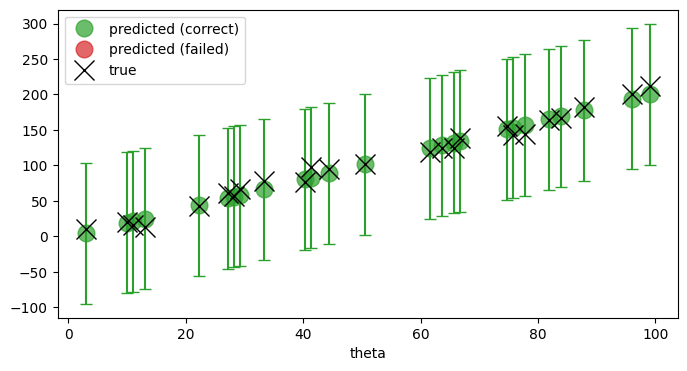

In [11]:
my_emulator.plot_diagnostics()

While `plot_diagnostics()` draws a set of diagnostics figures, individual diagnostics can be selected and drawn by calling specific `plot_*()` methods.